In [2]:
import plotly.express as px
import plotly

import pandas as pd
import numpy as np

In [4]:
np.random.seed(42)
df_plotly = pd.DataFrame({
    'X_Ekseni': np.random.randn(200),
    'Y_Ekseni': np.random.randn(200),
    'Z_Ekseni': np.random.randn(200),
    'Kategori': np.random.choice(['Alfa', 'Beta', 'Gama'], 200),
    'Guc_Seviyesi': np.random.uniform(10, 50, 200)
})

df_plotly

,X_Ekseni,Y_Ekseni,Z_Ekseni,Kategori,Guc_Seviyesi
0,0.496714,0.357787,-1.594428,Gama,23.672694
1,-0.138264,0.560785,-0.599375,Alfa,20.376937
2,0.647689,1.083051,0.005244,Beta,25.187696
3,1.523030,1.053802,0.046981,Gama,33.611798
4,-0.234153,-1.377669,-0.450065,Gama,20.722546
...,...,...,...,...,...
195,0.385317,-0.469176,-0.510016,Beta,45.351435
196,-0.883857,-1.713135,-0.269875,Beta,47.110091
197,0.153725,1.353872,-0.978764,Alfa,49.796313
198,0.058209,-0.114540,-0.444293,Gama,16.955810


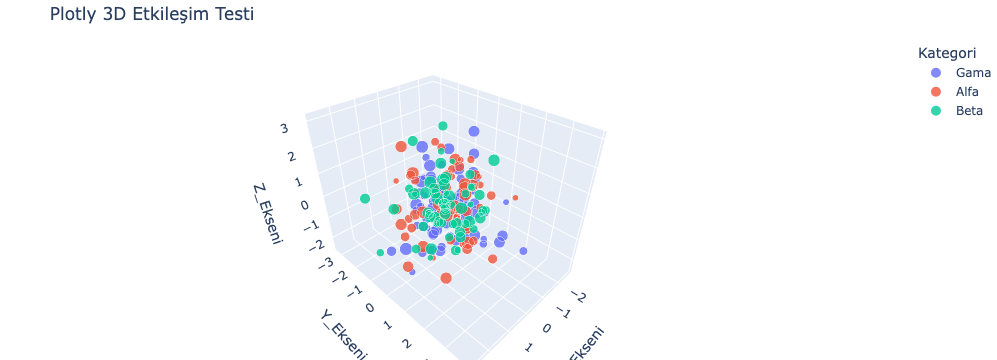

In [5]:
# Plotly Express ile tek satırda 3D Scatter Plot (Dağılım Grafiği) çizimi
fig = px.scatter_3d(
    df_plotly, 
    x='X_Ekseni', 
    y='Y_Ekseni', 
    z='Z_Ekseni',
    color='Kategori',          # Noktaların rengi kategoriye göre değişsin
    size='Guc_Seviyesi',       # Noktaların büyüklüğü güç seviyesine göre değişsin
    opacity=0.8,               # Hafif şeffaflık
    title="Plotly 3D Etkileşim Testi"
)

# Grafiği ekranın tam ortasında biraz daha büyük göstermek için boyut ayarı
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# Jupyter içinde render et!
fig.show()


In [9]:
import pydeck as pdk

In [7]:
# 1. Dış dosya kullanmadan 10.000 satırlık coğrafi veri üretimi
# İstanbul'un yaklaşık koordinatları (Enlem: 41.0082, Boylam: 28.9784) etrafında dağılım
np.random.seed(42)
df_geo = pd.DataFrame({
    'enlem': np.random.normal(41.0082, 0.04, 10000),
    'boylam': np.random.normal(28.9784, 0.05, 10000),
    'yogunluk': np.random.uniform(1, 10, 10000)
})

In [8]:
df_geo

,enlem,boylam,yogunluk
0,41.028069,28.944475,1.500998
1,41.002669,28.963125,9.871908
2,41.034108,28.948531,8.200166
3,41.069121,28.983921,8.819282
4,40.998834,29.038259,7.248649
...,...,...,...
9995,41.060244,28.997791,9.042527
9996,40.928266,29.047268,6.851782
9997,40.979987,28.997318,7.649712
9998,41.028031,29.064076,6.594953


In [10]:
# 2. PyDeck Katmanı (Layer) Oluşturma
# HexagonLayer, birbirine yakın noktaları birleştirip 3 boyutlu kuleler (altıgen prizmalar) oluşturur.
katman = pdk.Layer(
    'HexagonLayer',
    data=df_geo,
    get_position=['boylam', 'enlem'], # Dikkat: PyDeck önce boylam(X), sonra enlem(Y) ister!
    auto_highlight=True,
    elevation_scale=50,
    pickable=True,
    elevation_range=[0, 3000],
    extruded=True,                   # 3D kule görünümünü açar
    coverage=1
)

In [11]:
# 3. Kameranın Başlangıç Açısı ve Konumu (ViewState)
kamera_acisi = pdk.ViewState(
    longitude=28.9784,
    latitude=41.0082,
    zoom=10.5,
    min_zoom=5,
    max_zoom=15,
    pitch=45,       # 3D etkiyi hissetmek için kamerayı 45 derece eğiyoruz
    bearing=-20     # Haritayı hafifçe sağa döndürüyoruz
)


In [12]:
# 4. Haritayı Birleştir ve Render Et
# Herhangi bir API key gerektirmeyen Carto altyapısını kullanıyoruz

harita = pdk.Deck(
    layers=[katman], 
    initial_view_state=kamera_acisi, 
    map_provider='carto', 
    map_style='dark'
)

# Jupyter içinde göster
harita.show()

DeckGLWidget(carto_key=None, custom_libraries=[], google_maps_key=None, json_input='{\n  "initialViewState": {…